#### R2P Program Unit 4
# Estimating the Ground State Energy of $O_2$ with SQD

In this exercise, we focus on estimate the ground state of a familiar molecule, **the oxygen ($O_2$)** that we all breathe, using the **sample-based quantum diagonalization (SQD)** algorithm, and examine how quantum post-processing can improve energy estimates.

The workflow is as follows:
1. Use a quantum circuit to prepare an approximate ground state of $O_2$.
2. Sample measurement outcomes (bitstrings) from the circuit.
3. Apply the SQD algorithm to process these samples and obtain a more accurate energy estimate, even in the presence of quantum noise.

SQD takes noisy quantum measurements and processes them through a **classical recovery procedure** that:
- Preserves the symmetries of the molecule.
- Retains as much useful information as possible.
- Projects the Hamiltonian into a smaller subspace for more efficient classical diagonalization.

This approach allows large molecular Hamiltonians to be studied even when they are too large for direct classical simulation, while still producing meaningful results.

In [50]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import real_amplitudes
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import InstructionProperties
from qiskit.visualization import plot_distribution
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import ParameterVector

your_api_key = userdata.get('Qiskit')
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/6f00604460d04ea5bf731372db932526:037e3380-fea8-40e9-8c0e-e387e3e7c7c9::"

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    overwrite=True,
)

## Requirements

Before starting this tutorial, ensure that you have the following installed:

* Qiskit SDK 2.0 or later with visualization support (`pip install 'qiskit[visualization]'`)
* Qiskit Runtime 0.24 or later (`pip install qiskit-ibm-runtime`)
* Qiskit Addons SQD (`pip install qiskit-addon-sqd`)
* ffsim (`pip install ffsim`)


## Step 1: Map classical inputs to a quantum problem

To start off, we define the molecule object using the PySCF library by specifying the molecular structure, basis set, and other parameters. This object forms the basis for Hartree-Fock calculations and active space selection.


In [51]:
import pyscf
import pyscf.mcscf

distance = 1.16
a = distance / 2

mol = pyscf.gto.Mole()
mol.build(
    verbose=0,
    atom=[
        ["O", (0, 0, a)],
        ["O", (0, 0, -a)],
    ],
    basis="sto-6g",
    spin=0,
    charge=0,
    symmetry="d2h",
)
# Perform Hartree-Fock calculation
scf = pyscf.scf.RHF(mol).run()
# Freeze 1s core orbital on oxygen
n_frozen = 2
# Get number of atomic orbitals
n_orbitals = mol.nao_nr()
active_space = range(n_frozen, n_orbitals)

<a id="exercise1"></a>
<div class="alert alert-block alert-success">

    
<b> Exercise 1:</b>

In this exercise, you need to calculate the number of electrons in the active space and determine the number of spin-up and spin-down electrons. We will need that to build the quantum circuit to estimate the ground energy.

For this, you need to implement the following:

1. **Count the total number of electrons in the active space**:
   Use the molecular orbital occupation numbers (`scf.mo_occ`) and the active space indices (`active_space`) to count the total number of electrons.

2. **Determine the number of spin-up and spin-down electrons**:
   Use the total number of electrons and the molecular spin (`mol.spin`) to calculate:
   - `num_elec_a`: The number of spin-up electrons.
   - `num_elec_b`: The number of spin-down electrons.

<div style="text-align: center;">
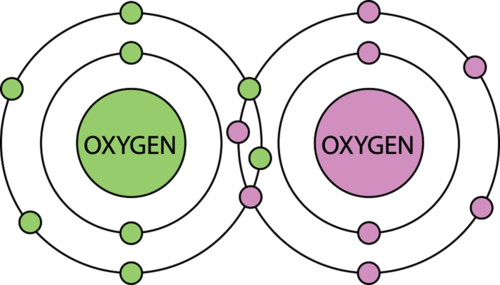
</div>

In [52]:

# Count electrons in active space
n_electrons = int(sum(scf.mo_occ[active_space]))
num_elec_a = (n_electrons + mol.spin) // 2
num_elec_b = (n_electrons + mol.spin) // 2

<a id="exercise2"></a>
<div class="alert alert-block alert-success">

<b>Exercise 2:</b>

Estimate the energy of the molecule using the Hartree-Fock method and the CASCI method.

1. Extract the Hartree-Fock energy from `scf`.  
2. Set up and execute a CASCI calculation to determine the exact energy. Ensure the active space is correctly defined, and the molecular orbitals are sorted appropriately.  
3. Compare the Hartree-Fock energy with the CASCI energy and observe the difference.

</div>

In [53]:
# Extract the Hartree-Fock energy from the SCF calculation
hf_energy= scf.e_tot

# Set up CASCI calculation
cas = pyscf.mcscf.CASCI(scf, len(active_space), (num_elec_a, num_elec_b))
# Sort molecular orbitals (MOs) to align the active space
mo = cas.sort_mo(active_space, base=0)
# Extract 1-electron and 2-electron integrals in the active space
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
num_orbitals = len(active_space)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)
# Run CASCI calculation
exact_energy = cas.run().e_tot

# Compare the Hartree-Fock energy with the CASCI energy
print(f"Hartree-Fock Energy: {hf_energy:.8f}")
print(f"CASCI Total Energy: {exact_energy:.8f}")


Hartree-Fock Energy: -148.95939735
CASCI Total Energy: -149.10204769


To build the LUCJ ansatz circuit we need to perform a CCSD calculation to obtain the [$t_1$ and $t_2$ amplitudes](https://en.wikipedia.org/wiki/Coupled_cluster#Cluster_operator) that will initialize the parameters of the ansatz.


Next, we use [ffsim](https://github.com/qiskit-community/ffsim) to create the ansatz circuit. We use the spin-balanced variant of the UCJ ansatz, [UCJOpSpinBalanced](https://qiskit-community.github.io/ffsim/api/ffsim.html#ffsim.UCJOpSpinBalanced).



<a id="exercise3"></a>
<div class="alert alert-block alert-success">

<b>Exercise 3:</b>

Create the quantum circuit that prepares the Hartree-Fock (HF) state and the LUCJ ansatz using `ffsim` and the amplitudes `t1` and `t2`.

1. Perform a CCSD calculation to obtain the `t1` and `t2` amplitudes.
2. Use the `UCJOpSpinBalanced` operator from `ffsim` to build the ansatz.
3. Construct a Qiskit quantum circuit that:
   - Prepares the HF reference state.
   - Applies the UCJ operator.

</div>

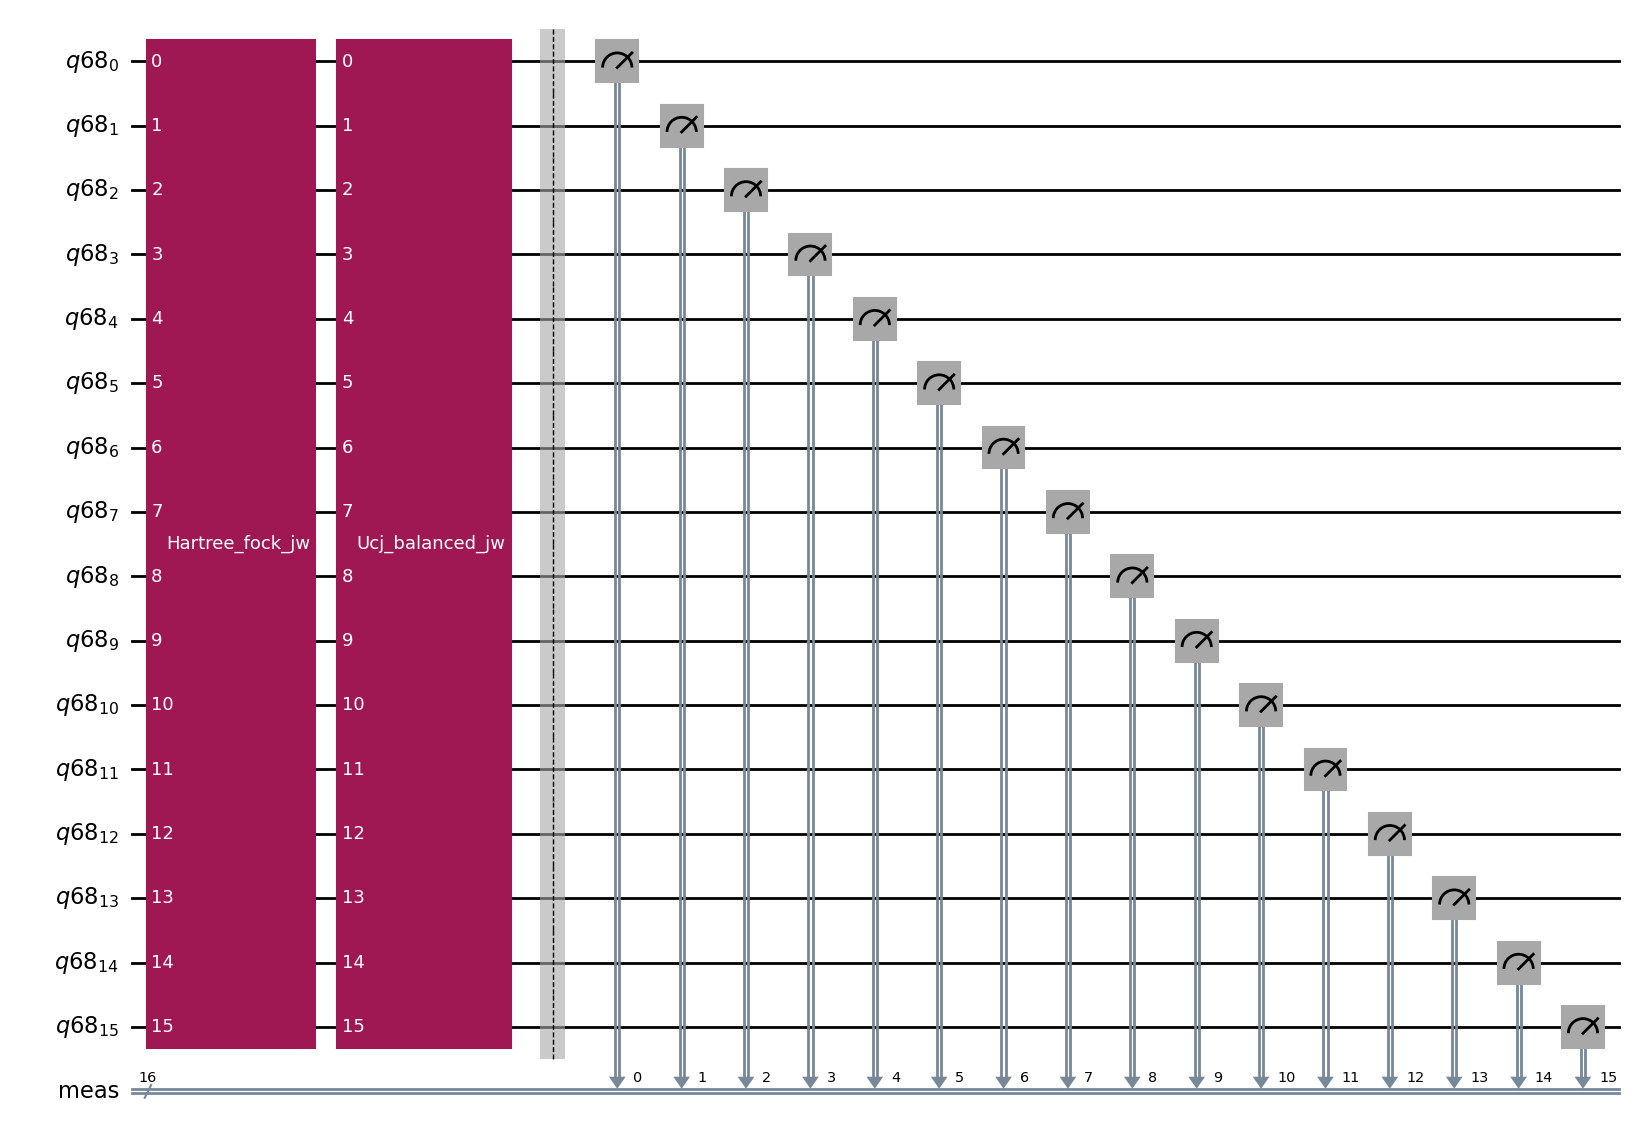

In [54]:
import ffsim
# Run CCSD with first orbital frozen
ccsd = pyscf.cc.CCSD(scf, frozen=n_frozen).run()

# Get amplitudes
t1 = ccsd.t1
t2 = ccsd.t2

# Build UCJ operator from CC amplitudes
n_reps = 1
alpha_alpha_indices = [(i, i + 1) for i in range(num_orbitals - 1)]
alpha_beta_indices = [(i, i) for i in range(0, num_orbitals, 4)]
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
)
from qiskit import QuantumCircuit, QuantumRegister
# Build quantum circuit
qubits = QuantumRegister(2 * num_orbitals)
circuit = QuantumCircuit(qubits)

# Prepare Hartree-Fock initial state
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, (num_elec_a, num_elec_b)), qubits)

# Apply UCJ operator
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)

circuit.measure_all()

# Show circuit (or export, etc.)
circuit.draw(output="mpl",fold=120)

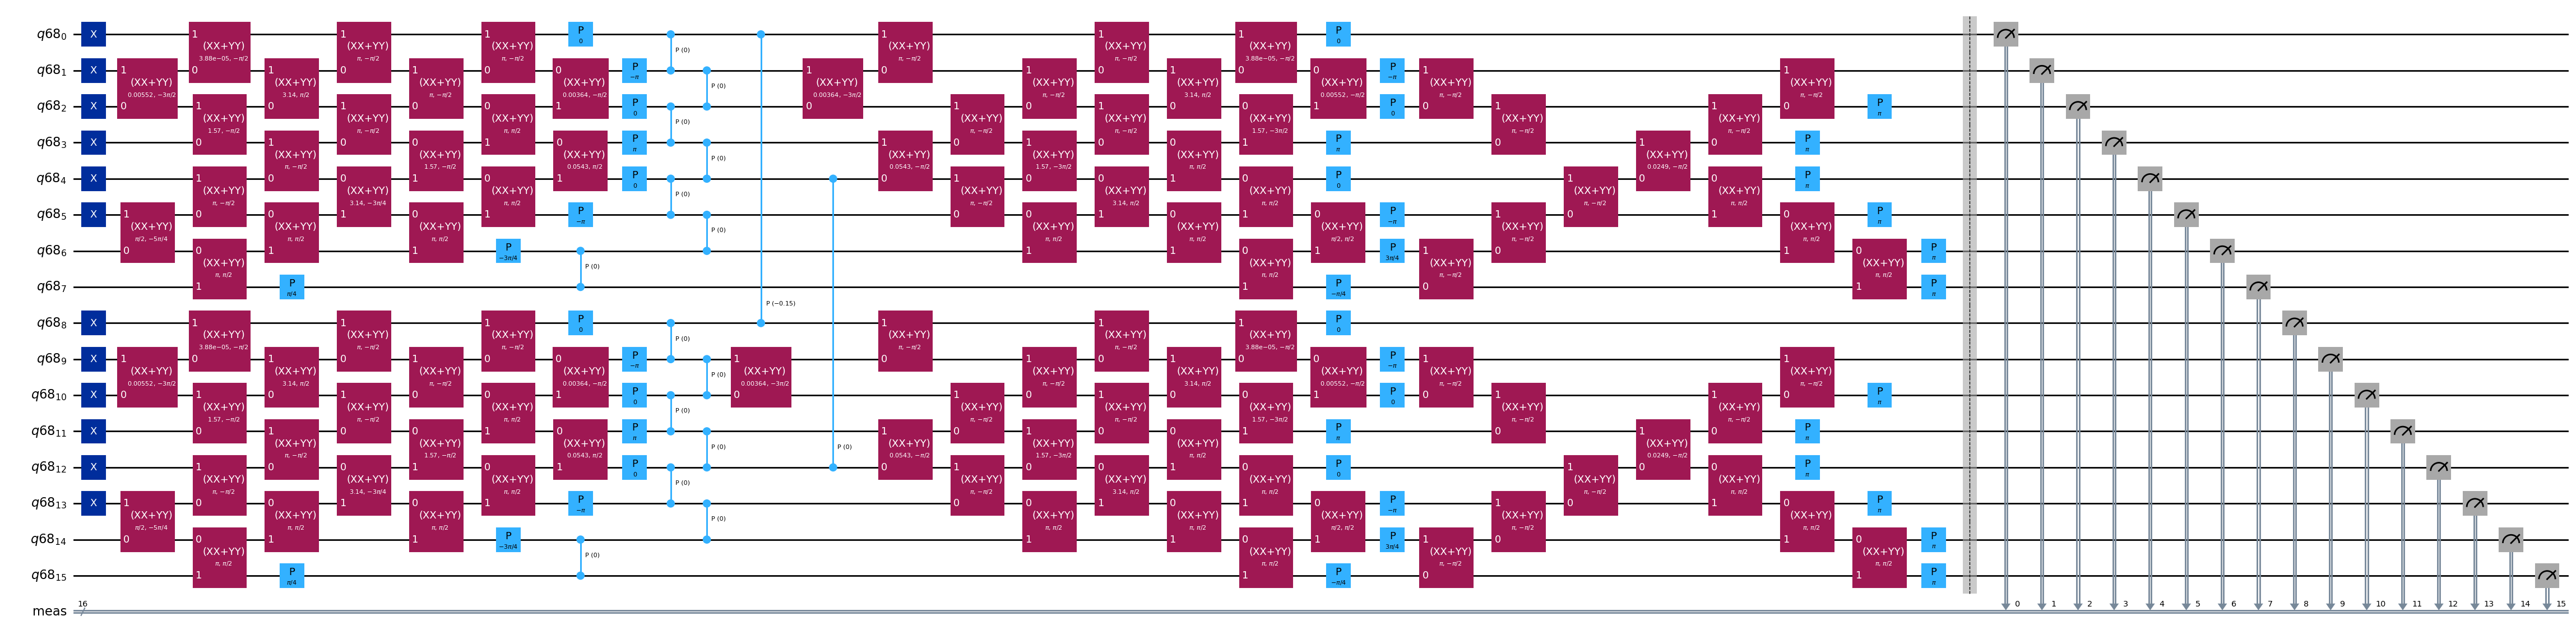

In [55]:
circuit.decompose().decompose().draw(output="mpl",fold=120)


## Step 2: Optimize problem for quantum execution


Next, we optimize the circuit for a target hardware. We'll use the least busy 156-qubit IBM QPU with a heavy-hex topology.


In [56]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Choose a real backend
service = QiskitRuntimeService(channel='ibm_quantum_platform',)
backend = service.least_busy(min_num_qubits=156)
# print backend details
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.backend_version}\n"
    f"No. of qubits: {backend.num_qubits}\n"
    f"Processor type: {backend.processor_type}\n"
)

Name: ibm_fez
Version: 1.3.37
No. of qubits: 156
Processor type: {'family': 'Heron', 'revision': '2'}



We transpile the circuit

In [57]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend
)

# without PRE_INIT passes
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/o pre-init passes): {isa_circuit.count_ops()}")

# with PRE_INIT passes

pass_manager.pre_init = ffsim.qiskit.PRE_INIT
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/ pre-init passes): {isa_circuit.count_ops()}")

Gate counts (w/o pre-init passes): OrderedDict({'sx': 266, 'rz': 261, 'cz': 122, 'x': 26, 'measure': 16, 'barrier': 1})
Gate counts (w/ pre-init passes): OrderedDict({'sx': 297, 'rz': 276, 'cz': 118, 'x': 16, 'measure': 16, 'barrier': 1})


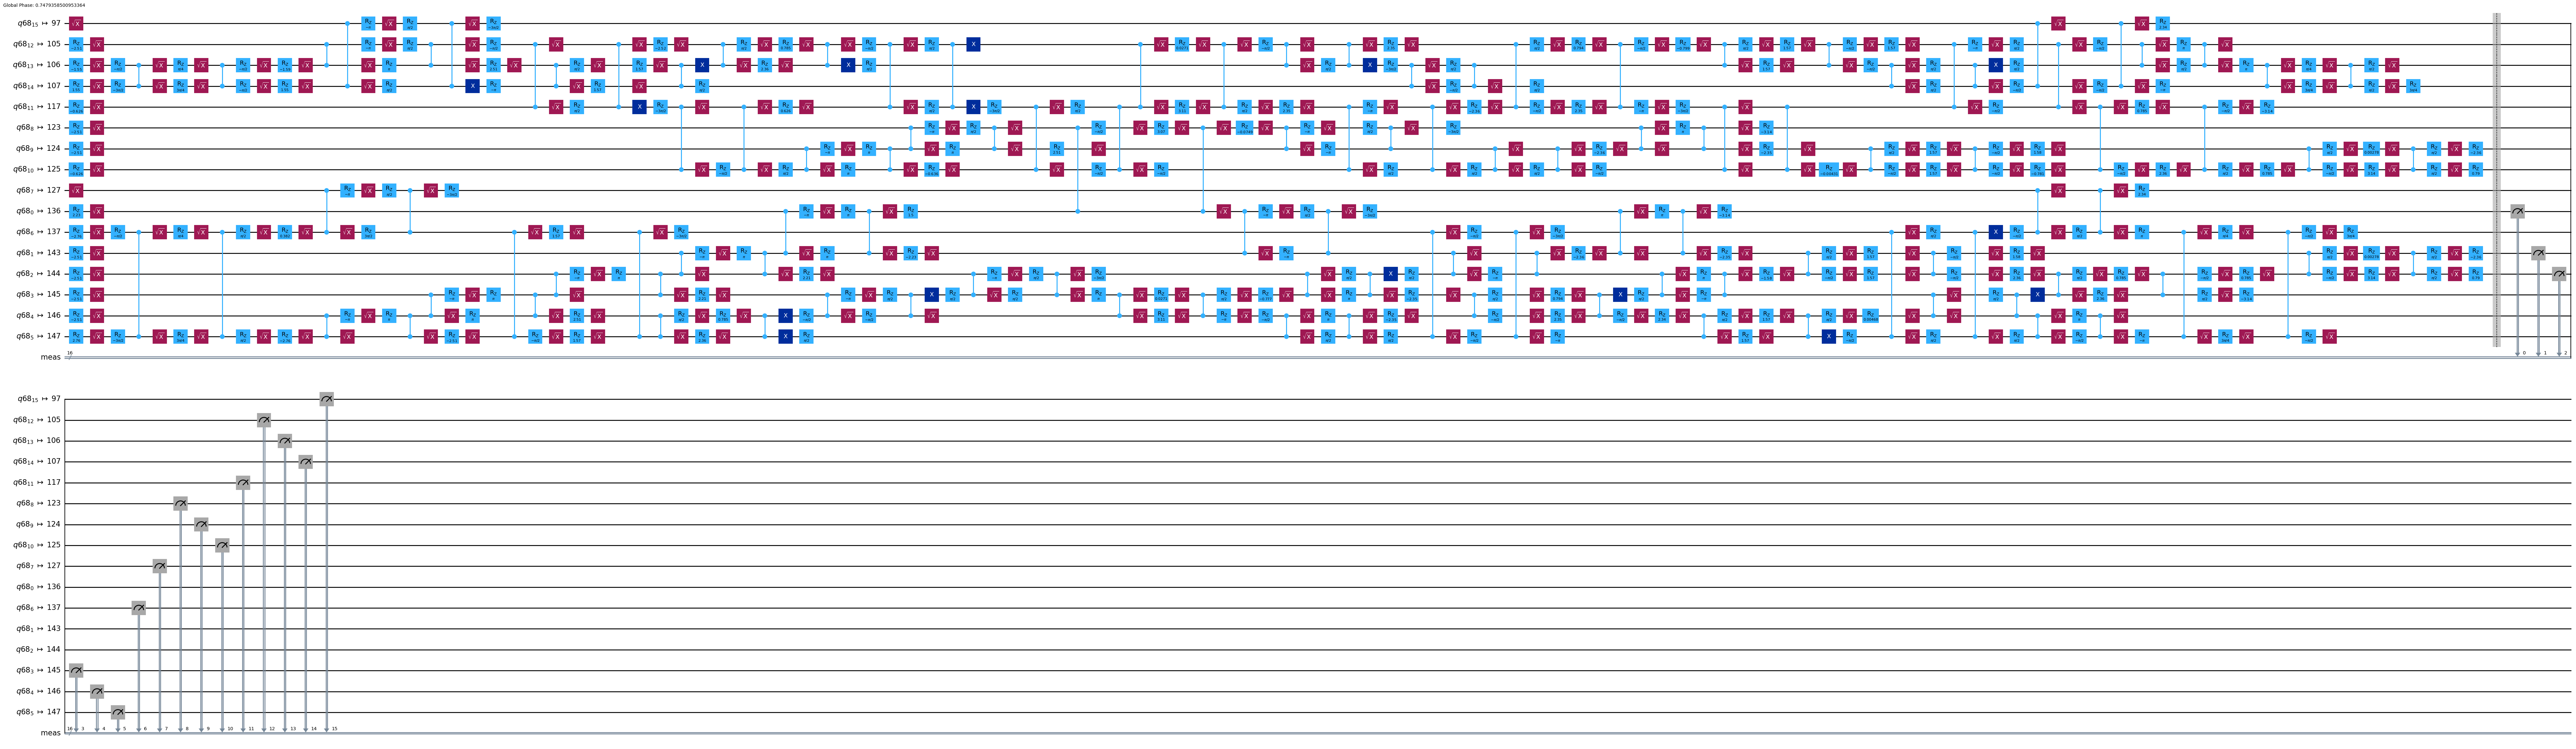

In [58]:
isa_circuit.draw(output="mpl",fold=120)

## Step 3: Execute using Qiskit Primitives


After optimizing the circuit for hardware execution, we are ready to run it on the target hardware and collect samples for ground state energy estimation. As we only have one circuit, we will use Qiskit Runtime's [Job execution mode](https://docs.quantum.ibm.com/guides/execution-modes) and execute our circuit.


In [59]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
sampler.options.environment.job_tags = ["R2P_CA"]
job = sampler.run([isa_circuit], shots=1000)

*Usage estimate: 2 seconds on an Heron r3 processor (NOTE: This is an estimate only. Your runtime might vary.)*

In [60]:
primitive_result = job.result()
pub_result = primitive_result[0]
counts = pub_result.data.meas.get_counts()

Now, we can take a look at the [Hamming weight](https://en.wikipedia.org/wiki/Hamming_weight) of the sampled basis states. Those with a Hamming weight equal to the number of electrons (12) respect the particle number symmetry, while the rest will be processed by SQD in the next stage to diagonalize the Hamiltonian in the corresponding reduced subspace.

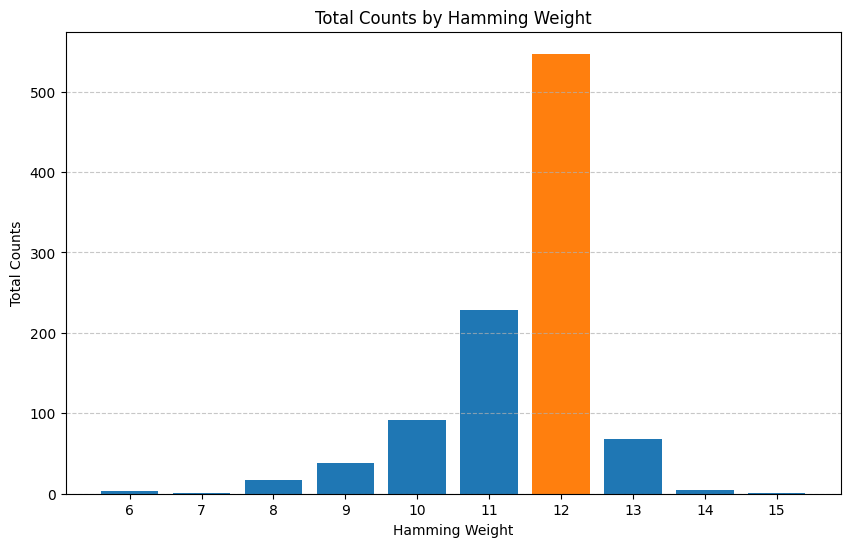

In [61]:
import matplotlib.pyplot as plt

# Groups total counts by Hamming weight (number of electrons).
hamming_weight_totals = {}
for bitstring, count in counts.items():
    weight = bitstring.count('1')
    hamming_weight_totals[weight] = hamming_weight_totals.get(weight, 0) + count

# Prepare data for plotting
weights = sorted(hamming_weight_totals.keys())
totals = [hamming_weight_totals[w] for w in weights]
colors = ['tab:orange' if w == (num_elec_a+num_elec_b) else 'tab:blue' for w in weights]

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(weights, totals, color=colors)
plt.xlabel('Hamming Weight')
plt.ylabel('Total Counts')
plt.title('Total Counts by Hamming Weight')
plt.xticks(weights)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

## Step 4: Post-process and return result to desired classical format


SQD relies significantly on post-processing the bitstrings collected from the quantum computer. To prepare for post-processing, we will convert the counts dictionary to a bit array, which is an $M \times N$ matrix of zeros and ones, where $M$ is the number of shots and $N$ is the number of qubits.

Note that in Qiskit's bit ordering convention, bitstrings are indexed starting from the right. Therefore, the bit array holds the measurement results of the first qubit in the rightmost column (the column with index $N - 1$). Furthermore, the spin-$\alpha$ orbitals are indexed before the spin-$\beta$ orbitals, which means that the spin-$\alpha$ orbitals are to the right of the spin-$\beta$ orbitals.


In [62]:
from qiskit_addon_sqd.counts import counts_to_arrays

# Convert counts into bitstring and probability arrays
bitstring_matrix_full, probs_arr_full = counts_to_arrays(counts)

<a id="exercise4"></a>
<div class="alert alert-block alert-success">

<b>Exercise 4:</b>

Modify the parameters of the self-consistent configuration recovery loop to achieve the following:

1. Ensure that the energy error is **greater in the first iteration**.
2. Ensure that the energy error **decreases** after some iterations and goes below `chem_accuracy = 0.001 Ha`.
3. Minimize the `iterations`, size of the batches (`samples_per_batch`) and the number of batches (`n_batches`) while achieving this goal.

To do so we might need to adjust the following parameters:
   - `iterations`: Number of iterations of the recovery loop.
   - `n_batches`: Number of batches of configurations to subsample.
   - `samples_per_batch`: Number of unique configurations in each batch.

**HINT:** If you are struggling to achieve this, try rerunning the job on the QPU to get a new set of 1000 samples. The performance of SQD depends on the *specific set of bitstrings* sampled by the quantum circuit. Different runs with the same circuit can yield different sets of valid configurations (for example, with different Hamming‑weight diversity), which in turn can affect how well the recovery loop converges toward the ground‑state energy.

</div>

In [63]:
# SQD options
iterations = 5
# Eigenstate solver options
n_batches = 3
samples_per_batch = 400

In [64]:
import numpy as np
rng=42
max_davidson_cycles = 200
from qiskit_addon_sqd.configuration_recovery import recover_configurations
from qiskit_addon_sqd.fermion import (
    bitstring_matrix_to_ci_strs,
    solve_fermion,
)
from qiskit_addon_sqd.subsampling import postselect_and_subsample

# Self-consistent configuration recovery loop
e_hist = np.zeros((iterations, n_batches))  # energy history
s_hist = np.zeros((iterations, n_batches))  # spin history
occupancy_hist = []
avg_occupancy = None
for i in range(iterations):
    print(f"Starting configuration recovery iteration {i}")
    # On the first iteration, we have no orbital occupancy information from the
    # solver, so we begin with the full set of noisy configurations.
    if avg_occupancy is None:
        bs_mat_tmp = bitstring_matrix_full
        probs_arr_tmp = probs_arr_full

    # If we have average orbital occupancy information, we use it to refine the full set of noisy configurations
    else:
        bs_mat_tmp, probs_arr_tmp = recover_configurations(
            bitstring_matrix_full,
            probs_arr_full,
            avg_occupancy,
            num_elec_a,
            num_elec_b,
            rand_seed=rng,
        )
    # Create batches of subsamples. We post-select here to remove configurations
    # with incorrect hamming weight during iteration 0, since no config recovery was performed.
    batches = postselect_and_subsample(
        bs_mat_tmp,
        probs_arr_tmp,
        hamming_right=num_elec_a,
        hamming_left=num_elec_b,
        samples_per_batch=samples_per_batch,
        num_batches=n_batches,
        rand_seed=rng,
    )

    # Run eigenstate solvers in a loop. This loop should be parallelized for larger problems.
    e_tmp = np.zeros(n_batches)
    s_tmp = np.zeros(n_batches)
    occs_tmp = []
    coeffs = []
    for j in range(n_batches):
        strs_a, strs_b = bitstring_matrix_to_ci_strs(batches[j])
        print(f"Batch {j} subspace dimension: {len(strs_a) * len(strs_b)}")
        energy_sci, coeffs_sci, avg_occs, spin = solve_fermion(
            batches[j],
            hcore,
            eri,
            open_shell=False,
            spin_sq=0,
            max_cycle=max_davidson_cycles,
        )
        energy_sci += nuclear_repulsion_energy
        e_tmp[j] = energy_sci
        s_tmp[j] = spin
        occs_tmp.append(avg_occs)
        coeffs.append(coeffs_sci)

    # Combine batch results
    avg_occupancy = tuple(np.mean(occs_tmp, axis=0))

    # Track optimization history
    e_hist[i, :] = e_tmp
    s_hist[i, :] = s_tmp
    occupancy_hist.append(avg_occupancy)

Starting configuration recovery iteration 0
Batch 0 subspace dimension: 441
Batch 1 subspace dimension: 441
Batch 2 subspace dimension: 441


/tmp/ipykernel_1256/2775667516.py:36: DeprecationWarning: The function ``qiskit_addon_sqd.subsampling.postselect_and_subsample()`` is deprecated as of qiskit-addon-sqd 0.12.0. It will be removed no earlier than v0.13.0. Instead, use the ``postselect_by_hamming_right_and_left`` and ``subsample`` functions.
  batches = postselect_and_subsample(


Starting configuration recovery iteration 1
Batch 0 subspace dimension: 729
Batch 1 subspace dimension: 729
Batch 2 subspace dimension: 729
Starting configuration recovery iteration 2
Batch 0 subspace dimension: 729
Batch 1 subspace dimension: 729
Batch 2 subspace dimension: 729
Starting configuration recovery iteration 3
Batch 0 subspace dimension: 729
Batch 1 subspace dimension: 729
Batch 2 subspace dimension: 729
Starting configuration recovery iteration 4
Batch 0 subspace dimension: 729
Batch 1 subspace dimension: 729
Batch 2 subspace dimension: 729


### Visualize the results

Now, we should observe how in the first iteration the error was greater than the accepted chemical accuracy (`chem_accuracy = 0.001 Ha`). However, as the iterations progress, the error decreases below the chemical accuracy. This demonstrates the effectiveness of leveraging the SQD algorithm to iteratively reduce the error while minimizing resource usage. By carefully selecting the number of batches, iterations, and samples per batch, we achieve accurate results while reducing the computational resources.


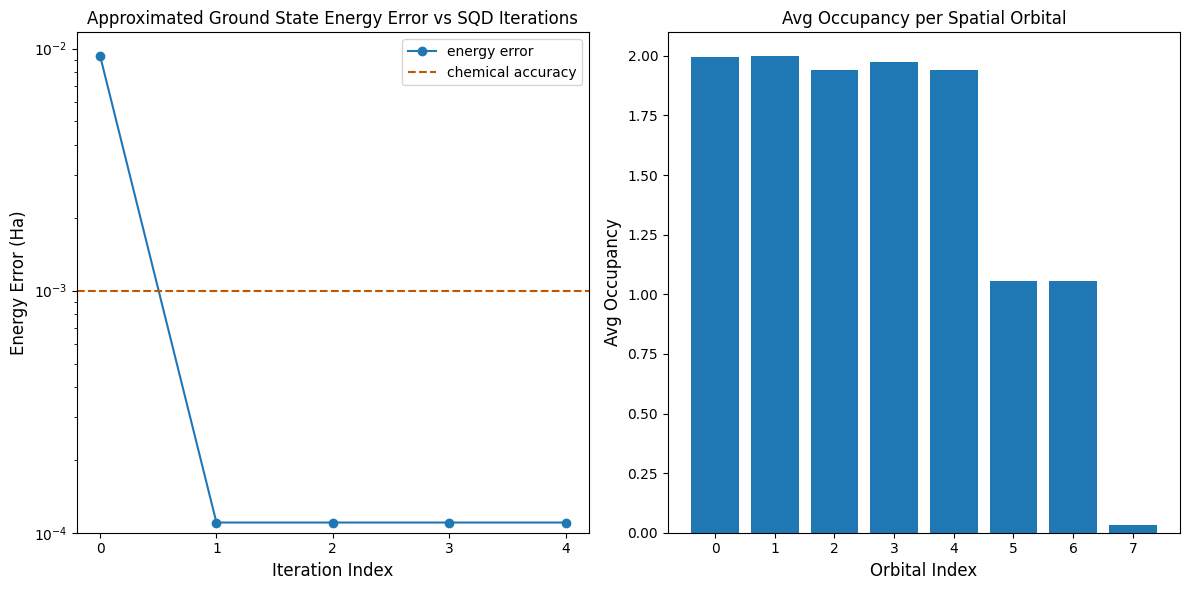

In [65]:
import matplotlib.pyplot as plt

# Data for energies plot
x1 = range(iterations)
e_diff = [abs(np.min(energies) - exact_energy) for energies in e_hist]
#yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4]

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001

# Data for avg spatial orbital occupancy
y2 = occupancy_hist[-1][0] + occupancy_hist[-1][1]
x2 = range(len(y2))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1)
#axs[0].set_yticks(yt1)
#axs[0].set_yticklabels(yt1)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-4)
axs[0].axhline(y=chem_accuracy, color="#BF5700", linestyle="--", label="chemical accuracy")
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations")
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 12})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 12})
axs[0].legend()

# Plot orbital occupancy
axs[1].bar(x2, y2, width=0.8)
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2)
axs[1].set_title("Avg Occupancy per Spatial Orbital")
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 12})
axs[1].set_ylabel("Avg Occupancy", fontdict={"fontsize": 12})

plt.tight_layout()
plt.show()

# Sample-based Krylov Quantum Diagonalization

Now we will find the ground state energy using Sample-based Krylov Quantum Diagonalization (SKQD).

We first define the krylov dimension and the number of Trotter steps and the step size:


###  Step 1: Map classical inputs to a quantum problem

In [66]:
# Set parameters for quantum Krylov algorithm
krylov_dim = 5  # size of krylov subspace
dt = 0.1
num_trotter_steps = 5

We define useful functions to express the Hamiltonian of $O_2$ as a `SparsePauliOp`

In [67]:
from qiskit.quantum_info import SparsePauliOp

def cholesky(V, eps):
    # see https://arxiv.org/pdf/1711.02242.pdf section B2
    # see https://arxiv.org/abs/1808.02625
    # see https://arxiv.org/abs/2104.08957
    no = V.shape[0]
    chmax, ng = 20 * no, 0
    W = V.reshape(no**2, no**2)
    L = np.zeros((no**2, chmax))
    Dmax = np.diagonal(W).copy()
    nu_max = np.argmax(Dmax)
    vmax = Dmax[nu_max]
    while vmax > eps:
        L[:, ng] = W[:, nu_max]
        if ng > 0:
            L[:, ng] -= np.dot(L[:, 0:ng], (L.T)[0:ng, nu_max])
        L[:, ng] /= np.sqrt(vmax)
        Dmax[: no**2] -= L[: no**2, ng] ** 2
        ng += 1
        nu_max = np.argmax(Dmax)
        vmax = Dmax[nu_max]
    L = L[:, :ng].reshape((no, no, ng))
    print(
        "accuracy of Cholesky decomposition ",
        np.abs(np.einsum("prg,qsg->prqs", L, L) - V).max(),
    )
    return L, ng

def identity(n):
    return SparsePauliOp.from_list([("I" * n, 1)])

def creators_destructors(n, mapping="jordan_wigner"):
    c_list = []
    if mapping == "jordan_wigner":
        for p in range(n):
            if p == 0:
                l, r = "I" * (n - 1), ""
            elif p == n - 1:
                l, r = "", "Z" * (n - 1)
            else:
                l, r = "I" * (n - p - 1), "Z" * p
            cp = SparsePauliOp.from_list([(l + "X" + r, 0.5), (l + "Y" + r, -0.5j)])
            c_list.append(cp)
    else:
        raise ValueError("Unsupported mapping.")
    d_list = [cp.adjoint() for cp in c_list]
    return c_list, d_list


def build_hamiltonian(ecore: float, h1e: np.ndarray, h2e: np.ndarray) -> SparsePauliOp:
    ncas, _ = h1e.shape

    C, D = creators_destructors(2 * ncas, mapping="jordan_wigner")
    Exc = []
    for p in range(ncas):
        Excp = [C[p] @ D[p] + C[ncas + p] @ D[ncas + p]]
        for r in range(p + 1, ncas):
            Excp.append(
                C[p] @ D[r]
                + C[ncas + p] @ D[ncas + r]
                + C[r] @ D[p]
                + C[ncas + r] @ D[ncas + p]
            )
        Exc.append(Excp)

    # low-rank decomposition of the Hamiltonian
    Lop, ng = cholesky(h2e, 1e-6)
    t1e = h1e - 0.5 * np.einsum("pxxr->pr", h2e)

    H = ecore * identity(2 * ncas)
    # one-body term
    for p in range(ncas):
        for r in range(p, ncas):
            H += t1e[p, r] * Exc[p][r - p]
    # two-body term
    for g in range(ng):
        Lg = 0 * identity(2 * ncas)
        for p in range(ncas):
            for r in range(p, ncas):
                Lg += Lop[p, r, g] * Exc[p][r - p]
        H += 0.5 * Lg @ Lg

    return H.chop().simplify()

Create the Hamiltonian

In [68]:
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
num_orbitals = len(active_space)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)
hamiltonian_o2 = build_hamiltonian(nuclear_repulsion_energy, hcore, eri)

accuracy of Cholesky decomposition  2.220446049250313e-16


<a id="exercise5"></a>
<div class="alert alert-block alert-success">

<b>Exercise 5:</b>

Define the Hartree-Fock initial state for SKQD

</div>

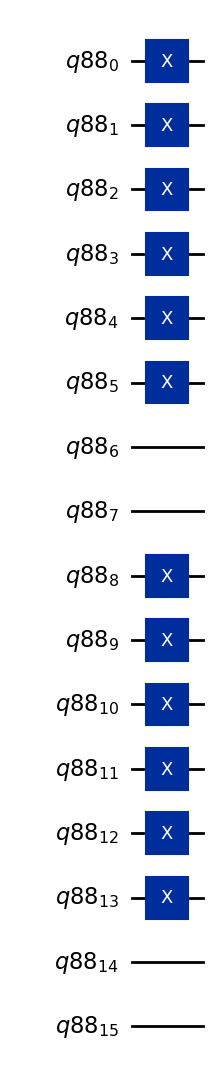

In [69]:
# Build quantum circuit
qubits = QuantumRegister(2 * num_orbitals)
circuit_skqd = QuantumCircuit(qubits)

# Generate the Hartree Fock state
circuit_skqd.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, (num_elec_a, num_elec_b)), qubits)

circuit_skqd.decompose().decompose().draw(output="mpl",fold=120)

<a id="exercise6"></a>
<div class="alert alert-block alert-success">

<b>Exercise 6:</b>

Define the time-evolution circuits for the SKQD

</div>

In [70]:
from qiskit.circuit import QuantumRegister
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter

evol_gate = PauliEvolutionGate(hamiltonian_o2, time=(dt / num_trotter_steps), synthesis=LieTrotter(reps=num_trotter_steps))

qr = QuantumRegister(2*num_orbitals)
qc_evol = QuantumCircuit(qr)
qc_evol.append(evol_gate, qargs=qr)

circuits = []
for rep in range(krylov_dim):
    # Repeating the `U` operator to implement U^0, U^1, U^2, and so on, for power Krylov space
    # add your code here
    circ = circuit_skqd.copy()

    # Repeating the `U` operator to implement U^0, U^1, U^2, and so on, for power Krylov space
    for i in range(rep):
        circ.compose(other=qc_evol, inplace=True)

    circ.measure_all()
    circuits.append(circ)

### Step 2: Optimize for target hardware

In [71]:
# Choose a real backend
service = QiskitRuntimeService(channel='ibm_quantum_platform',)
backend = service.least_busy(min_num_qubits=156)
# print backend details
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.backend_version}\n"
    f"No. of qubits: {backend.num_qubits}\n"
    f"Processor type: {backend.processor_type}\n"
)

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuits = pm.run(circuits=circuits)

Name: ibm_fez
Version: 1.3.37
No. of qubits: 156
Processor type: {'family': 'Heron', 'revision': '2'}



###  Step 3: Execute on target hardware

<div class="alert alert-block alert-warning">
    
*Usage estimate: 12 minutes and 21 seconds on an Heron r3 processor (NOTE: This is an estimate only. Your runtime might vary.)*
</div>

In [73]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
sampler.options.environment.job_tags = ["R2P_CA"]
job = sampler.run(isa_circuits, shots=5000)

In [74]:
counts_all = [job.result()[k].data.meas.get_counts() for k in range(krylov_dim)]

###  Step 4: Post-process

In [75]:
from collections import Counter

counts_cumulative = []
for i in range(krylov_dim):
    counter = Counter()
    for d in counts_all[: i + 1]:
        counter.update(d)

    counts = dict(counter)
    counts_cumulative.append(counts)
from qiskit_addon_sqd.counts import counts_to_arrays
from qiskit_addon_sqd.qubit import solve_qubit
# Filters out bitstrings that do not have specified number (`num_ones`) of `1` bits.
def postselect_counts(counts, num_ones):
    filtered_counts = {}
    for bitstring, freq in counts.items():
        if bitstring.count("1") == num_ones:
            filtered_counts[bitstring] = freq

    return filtered_counts

In [76]:
from qiskit.quantum_info import Statevector
scipy_kwargs = {"k": 1, "which": "SA"}

ground_state_energies = []
for counts in counts_cumulative:
    counts = postselect_counts(counts, num_ones=num_elec_a+num_elec_b)
    bitstring_matrix, probs = counts_to_arrays(counts=counts)
    if len(probs)<3:
        most_probable = max(counts, key=counts.get)
        eigenstate = np.array([int(bit) for bit in most_probable])[np.newaxis, :]
        eigenval = np.real(Statevector.from_label(most_probable).expectation_value(hamiltonian_o2))

    else:
        eigenval, eigenstate = solve_qubit(
            bitstring_matrix, hamiltonian_o2, verbose=False, **scipy_kwargs
        )
    ground_state_energies.append(eigenval)

### Visualize the results

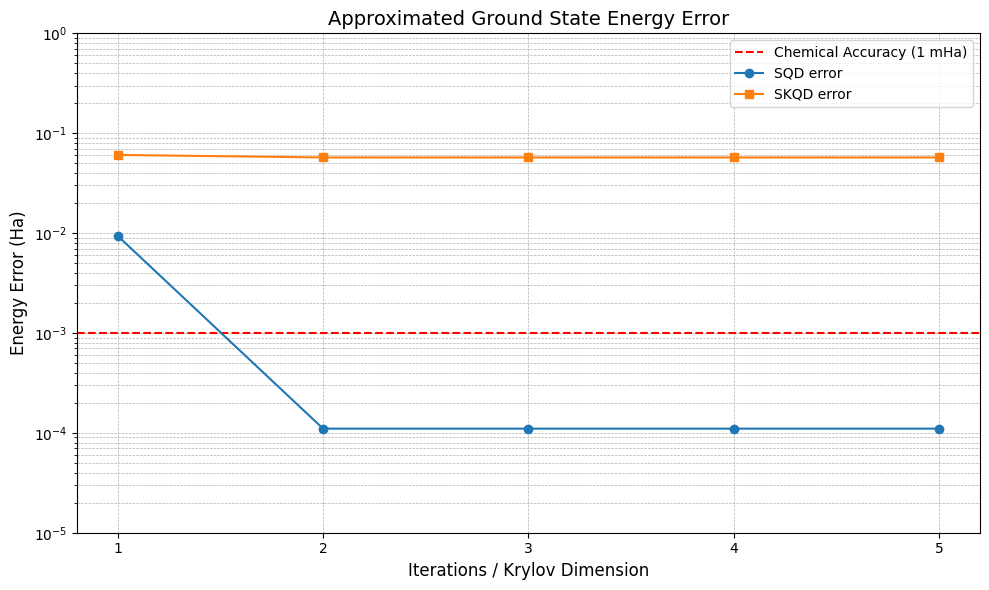

In [77]:
import matplotlib.ticker as ticker
# Data for energies plot
x1 = range(1, krylov_dim + 1)
e_diff_skd = [abs(np.min(energies) - exact_energy) for energies in ground_state_energies]
e_diff_sqd = [abs(np.min(energies) - exact_energy) for energies in e_hist]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001
ax.axhline(y=chem_accuracy, color='red', linestyle='--', label='Chemical Accuracy (1 mHa)')

ax.plot(x1, e_diff_sqd, label="SQD error", marker="o")
ax.plot(x1, e_diff_skd, label="SKQD error", marker="s")

ax.set_yscale("log")
ax.set_xticks(x1)
ax.set_title("Approximated Ground State Energy Error", fontsize=14)
ax.set_xlabel("Iterations / Krylov Dimension", fontsize=12)
ax.set_ylabel("Energy Error (Ha)", fontsize=12)
ax.set_yticks(yt1, labels=[str(y) for y in yt1])
ax.get_yaxis().set_major_formatter(ticker.LogFormatterSciNotation())

ax.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

How are they performing?
<a id="exercise7"></a>
<div class="alert alert-block alert-success">

<b>Optional:</b>

Use a recovery configuration for SKQD and rerun the algorithm to compare the results with SQD

</div>